Here's the first script of the project, we test pulling one week of pricing data for germany. With the ensoe library, we can just use the code "DE_LU" for the market instead of the more complicated codes involved in the api. 

In [ ]:
#remember to make sure you have the entsoe-py library installed. You can do this by running pip install entsoe-py in your terminal.
from dotenv import load_dotenv
import os
from entsoe import EntsoePandasClient
import pandas as pd

load_dotenv()  # reads .env and loads its variables into the environment, for this to work you need to have a .env file in the same directory as this script with the line: ENTSOE_API_KEY=your_api_key_here

#Below is the API call to get the day-ahead prices for Germany and Luxembourg (DE_LU) for the first week of January 2026.
client = EntsoePandasClient(api_key=os.environ["ENTSOE_API_KEY"])

start = pd.Timestamp('2026-01-01', tz='Europe/Berlin')
end   = pd.Timestamp('2026-01-08', tz='Europe/Berlin')

# Below is the actual call

de_prices = client.query_day_ahead_prices('DE_LU', start=start, end=end)
print(de_prices.head())

2026-01-01 00:00:00+01:00    63.64
2026-01-01 00:15:00+01:00    61.48
2026-01-01 00:30:00+01:00    58.00
2026-01-01 00:45:00+01:00    49.99
2026-01-01 01:00:00+01:00    60.01
dtype: float64


ok so we seem to get a series rather than a data frame, cool cool. But it works! 

In [2]:
de_prices.info()

<class 'pandas.Series'>
DatetimeIndex: 673 entries, 2026-01-01 00:00:00+01:00 to 2026-01-08 00:00:00+01:00
Series name: None
Non-Null Count  Dtype  
--------------  -----  
673 non-null    float64
dtypes: float64(1)
memory usage: 10.5 KB


In [3]:
de_prices

2026-01-01 00:00:00+01:00    63.64
2026-01-01 00:15:00+01:00    61.48
2026-01-01 00:30:00+01:00    58.00
2026-01-01 00:45:00+01:00    49.99
2026-01-01 01:00:00+01:00    60.01
                             ...  
2026-01-07 23:00:00+01:00    95.11
2026-01-07 23:15:00+01:00    89.01
2026-01-07 23:30:00+01:00    86.83
2026-01-07 23:45:00+01:00    84.10
2026-01-08 00:00:00+01:00    86.88
Length: 673, dtype: float64

lets try south swedish prices, pricing zone 4

In [5]:
se_prices = client.query_day_ahead_prices('SE_4', start=start, end=end)
print(se_prices.head())

2026-01-01 00:00:00+01:00    41.58
2026-01-01 00:15:00+01:00    40.87
2026-01-01 00:30:00+01:00    40.20
2026-01-01 00:45:00+01:00    39.23
2026-01-01 01:00:00+01:00    38.30
dtype: float64


success! Woop woop. Ok, now lets play with them.

Text(0.5, 1.0, 'Day-ahead prices, first week of Jan 2026')

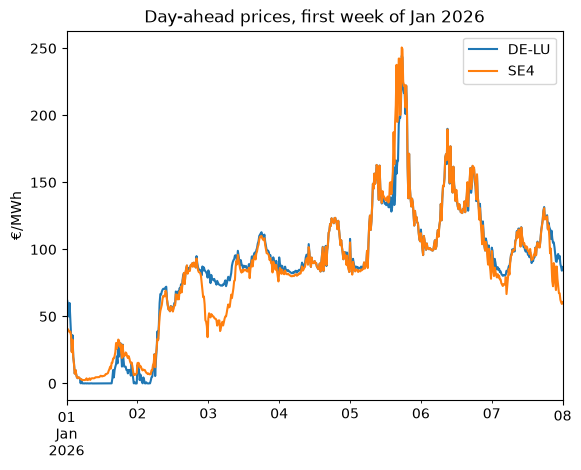

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

de_prices.plot(ax=plt.gca(), label='DE-LU')
se_prices.plot(ax=plt.gca(), label='SE4')
plt.legend()
plt.ylabel('€/MWh')
plt.title('Day-ahead prices, first week of Jan 2026')